---
tags: [integration, optimization, variational]
---

# QURI Parts Support

This page introduces Qamomile's [QURI Parts](https://quri-parts.qunasys.com/) backend through a concrete optimization problem. We model a small MaxCut instance as an Ising problem with `BinaryModel.from_ising`, compile it into a QAOA ansatz with `QAOAConverter`, and run it through `QuriPartsTranspiler` / `QuriPartsExecutor`. `QuriPartsExecutor` uses [Qulacs](https://docs.qulacs.org/), a fast C++ state-vector simulator, by default, so the examples below run on a local CPU without any extra configuration.

In [1]:
# Install the latest Qamomile with the QURI Parts extras through pip!
# !pip install "qamomile[quri_parts]"

## The MaxCut problem

We reuse the small 5-node graph from the [QAOA for MaxCut tutorial](../algorithm/qaoa_maxcut.ipynb) so the focus stays on the QURI Parts integration rather than on QAOA itself. Maximizing $\sum_{(i,j) \in E}(1 - s_i s_j)/2$ is equivalent, up to a constant, to *minimizing* the antiferromagnetic Ising Hamiltonian $H_C = \sum_{(i,j) \in E} s_i s_j$. For unweighted MaxCut, every $J_{ij} = 1$ and every $h_i = 0$, so we pass these coefficients directly to `BinaryModel.from_ising`.

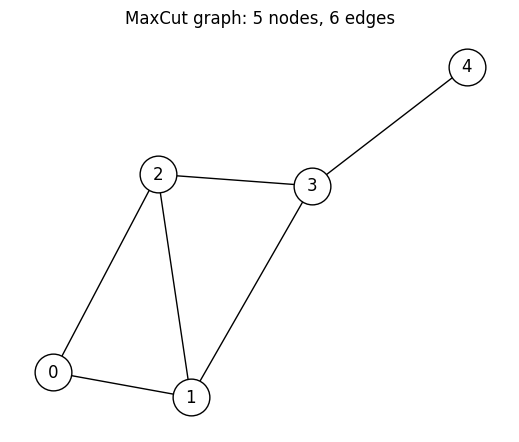

In [2]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

from qamomile.optimization.binary_model import BinaryModel

G = nx.Graph()
G.add_edges_from([(0, 1), (0, 2), (1, 2), (1, 3), (2, 3), (3, 4)])
num_nodes = G.number_of_nodes()

ising_quad: dict[tuple[int, int], float] = {
    tuple(sorted((i, j))): 1.0 for i, j in G.edges()
}
spin_model = BinaryModel.from_ising(linear={}, quad=ising_quad)

pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(5, 4))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="white",
    node_size=700,
    edgecolors="black",
)
plt.title(f"MaxCut graph: {num_nodes} nodes, {G.number_of_edges()} edges")
plt.show()

## Compiling QAOA with `QuriPartsTranspiler`

`QAOAConverter` consumes a `BinaryModel` (or OMMX instance), exposes a Pauli-Z cost Hamiltonian via `get_cost_hamiltonian()`, and emits a measurement-terminated QAOA sampling kernel via `transpile(transpiler, p=p)`. Using `QuriPartsTranspiler()` only requires changing the transpiler argument, because the converter works with any backend supported by Qamomile.

In [3]:
from qamomile.optimization.qaoa import QAOAConverter
from qamomile.quri_parts import QuriPartsExecutor, QuriPartsTranspiler

p = 3  # number of QAOA layers

converter = QAOAConverter(spin_model)
cost_hamiltonian = converter.get_cost_hamiltonian()
print("Cost Hamiltonian:")
print(cost_hamiltonian)

transpiler = QuriPartsTranspiler()
executor = QuriPartsExecutor()

executable = converter.transpile(transpiler, p=p)

Cost Hamiltonian:
Hamiltonian((Z0, Z1): 1.0, (Z0, Z2): 1.0, (Z1, Z2): 1.0, (Z1, Z3): 1.0, (Z2, Z3): 1.0, (Z3, Z4): 1.0)


Inspect the resulting QURI Parts circuit to confirm that it is a linear-mapped parametric circuit and that the $2p$ QAOA angles (`gammas[0..p-1]`, `betas[0..p-1]`) remain available as named runtime parameters:

In [4]:
quri_circuit = executable.get_first_circuit()
assert quri_circuit is not None  # transpile() always emits one quantum segment here
print(type(quri_circuit).__name__)
print("qubit_count    :", quri_circuit.qubit_count)
print("parameter_count:", quri_circuit.parameter_count)

LinearMappedParametricQuantumCircuit
qubit_count    : 5
parameter_count: 6


At runtime, this object is QURI Parts' linear-mapped parametric circuit (`LinearMappedParametricQuantumCircuit`, aliased as `LinearMappedUnboundParametricQuantumCircuit` in the public API). Each runtime parameter slot stays unbound until execution time, so binding `gammas` / `betas` is a cheap numeric update on the QURI Parts side rather than a circuit rebuild. The problem structure (Ising coefficients, qubit count, and depth) is fixed at compile time, leaving only the variational angles as runtime inputs.

## Sampling QAOA with `QuriPartsExecutor`

`executable.sample(executor, bindings=..., shots=...)` returns a `SampleJob`. Calling `.result()` gives a `SampleResult`, which the converter can decode into a `BinarySampleSet` already in the spin domain (+1 / -1). That means cut edges can be counted directly, with no additional conversion. `QuriPartsExecutor()` runs against the Qulacs state-vector simulator by default.

In [5]:
rng = np.random.default_rng(42)
init_params = rng.uniform(-np.pi / 2, np.pi / 2, 2 * p)
init_gammas = list(init_params[:p])
init_betas = list(init_params[p:])

sample_result = executable.sample(
    executor,
    bindings={"gammas": init_gammas, "betas": init_betas},
    shots=2000,
).result()

decoded = converter.decode_to_binary_sampleset(sample_result)
print(f"Mean energy at random init: {decoded.energy_mean():+.4f}")

Mean energy at random init: -0.6060


## Optimizing the QAOA parameters

A typical QAOA optimization loop reuses the same `executable` across many `(gammas, betas)` vectors: call `converter.transpile()` once, then call `executable.sample()` many times. Below, we wrap the sample-and-decode step in SciPy's `minimize` driver. The classical optimizer updates `(gammas, betas)` to minimize the mean sampled Ising energy, while every iteration reuses the same `executable` and `QuriPartsExecutor`.

In [6]:
from scipy.optimize import minimize

cost_history: list[float] = []


def cost_fn(params: np.ndarray) -> float:
    result = executable.sample(
        executor,
        bindings={"gammas": list(params[:p]), "betas": list(params[p:])},
        shots=2000,
    ).result()
    energy = converter.decode_to_binary_sampleset(result).energy_mean()
    cost_history.append(energy)
    return energy


res = minimize(cost_fn, init_params, method="COBYLA", options={"maxiter": 100})

opt_gammas = list(res.x[:p])
opt_betas = list(res.x[p:])
print(f"Optimized mean energy: {res.fun:+.4f}")
print(f"Optimal gammas       : {[round(float(v), 4) for v in opt_gammas]}")
print(f"Optimal betas        : {[round(float(v), 4) for v in opt_betas]}")

Optimized mean energy: -2.8570
Optimal gammas       : [0.7933, -0.3716, 1.3248]
Optimal betas        : [0.4546, -0.862, 2.9664]


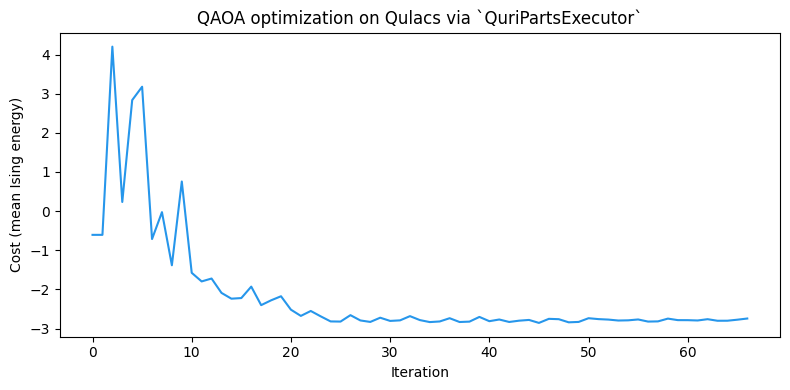

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(cost_history, color="#2696EB")
plt.xlabel("Iteration")
plt.ylabel("Cost (mean Ising energy)")
plt.title("QAOA optimization on Qulacs via `QuriPartsExecutor`")
plt.tight_layout()
plt.show()

The Qulacs sampler used inside `QuriPartsExecutor` does not seed its per-shot RNG, so the exact trajectory and final energy will vary slightly across runs. The optimizer should still converge close to the ground-state energy of $H_C$ on this 5-node graph. The optimized parameters above (`opt_gammas`, `opt_betas`) are reused throughout the rest of this page.

## Expectation values: unbound-parametric vs. bound-circuit dispatch

`QuriPartsExecutor.estimate_expectation(circuit, hamiltonian, param_values)` is the QURI Parts-native entry point for expectation-value evaluation. It automatically dispatches between two different QURI Parts estimators depending on the **state of the circuit it receives**:

- **Unbound parametric circuit**: the linear-mapped circuit produced by `transpile()` still has free parameters. QURI Parts' `apply_circuit` wraps it as a `ParametricCircuitQuantumState`, and the executor routes the call through QURI Parts' **parametric estimator**, using `param_values` to bind the parameters at evaluation time.
- **Bound or non-parametric circuit**: once parameters are bound (for example, via `circuit.bind_parameters([...])`), the same `apply_circuit` call produces a `GeneralCircuitQuantumState`. The executor falls back to QURI Parts' **non-parametric estimator**, and `param_values` is ignored.

Knowing which path is used matters because the two estimators have different cost profiles. The parametric estimator is the right tool inside a tight optimization loop because it avoids a per-iteration circuit copy. The non-parametric estimator avoids parametric bookkeeping when the parameters are already concrete.

QURI Parts treats `measure` as a no-op at the circuit level, so the parametric circuit emitted by `converter.transpile()` represents exactly the QAOA state preparation $|\boldsymbol{\gamma}, \boldsymbol{\beta}\rangle$. We can pass it directly to `estimate_expectation` together with the cost Hamiltonian to compute $\langle H_C \rangle$ analytically, with no sampling noise. Inside a QAOA optimizer, you can therefore keep the same circuit and replace `executable.sample()` + decode with `executor.estimate(circuit, hamiltonian, params=...)`.

To exercise both estimator paths directly, build a QURI Parts Operator from the converter's cost Hamiltonian and call `estimate_expectation` on each circuit variant:

In [8]:
from qamomile.quri_parts.observable import hamiltonian_to_quri_operator

quri_H = hamiltonian_to_quri_operator(cost_hamiltonian)

# The unbound parametric circuit straight out of converter.transpile().
unbound_circuit = executable.get_first_circuit()
assert unbound_circuit is not None
print(f"unbound type           : {type(unbound_circuit).__name__}")
print(f"unbound parameter_count: {unbound_circuit.parameter_count}")

# QURI Parts requires the runtime parameters as a flat list in the order
# they were registered on the circuit, which is first-use order during
# emission. For QAOA that means gammas[0], betas[0], gammas[1], betas[1],
# ..., interleaved per layer, NOT all gammas followed by all betas.
# Read the order from the executable and build the flat list by lookup so
# we never have to guess the convention.
named_values = {f"gammas[{i}]": opt_gammas[i] for i in range(p)}
named_values.update({f"betas[{i}]": opt_betas[i] for i in range(p)})
flat_params = [named_values[name] for name in executable.parameter_names]
print(f"circuit parameter order: {executable.parameter_names}")

# Manually bind the same numeric values using QURI Parts' native binder.
bound_circuit = unbound_circuit.bind_parameters(flat_params)
print(f"bound   type           : {type(bound_circuit).__name__}")

# Path 1: unbound -> parametric estimator. param_values is consumed.
energy_unbound = executor.estimate_expectation(
    unbound_circuit, quri_H, flat_params
)

# Path 2: bound -> non-parametric estimator. param_values is ignored.
energy_bound = executor.estimate_expectation(bound_circuit, quri_H, [])

print(f"parametric  estimator: {energy_unbound:+.10f}")
print(f"non-param.  estimator: {energy_bound:+.10f}")
assert np.isclose(energy_unbound, energy_bound, atol=1e-10)

unbound type           : LinearMappedParametricQuantumCircuit
unbound parameter_count: 6
circuit parameter order: ['gammas[0]', 'betas[0]', 'gammas[1]', 'betas[1]', 'gammas[2]', 'betas[2]']
bound   type           : ImmutableBoundParametricQuantumCircuit
parametric  estimator: -2.7780522247
non-param.  estimator: -2.7780522247


Both paths agree to numerical precision because they evaluate the same QAOA state against the same Ising cost Hamiltonian. The resulting noise-free expectation value at the optimized parameters should also match the optimized sample-mean energy printed earlier within shot noise. The dispatch is invisible to callers who stay inside Qamomile's `executor.estimate()` interface. Reach for `estimate_expectation` directly only when you need to manage the QURI Parts circuit yourself.

`executor.estimate(circuit, hamiltonian, params=...)` is the higher-level variant. It accepts a `qamomile.observable.Hamiltonian` directly, converts it automatically, and then delegates to `estimate_expectation`:

In [9]:
energy_via_estimate = executor.estimate(
    unbound_circuit, cost_hamiltonian, params=flat_params
)
print(f"executor.estimate     : {energy_via_estimate:+.10f}")
assert np.isclose(energy_via_estimate, energy_unbound, atol=1e-10)

executor.estimate     : -2.7780522247


## Customizing the sampler and estimator

`QuriPartsExecutor()` lazily creates the default Qulacs sampler and parametric estimator on first use. To plug in a different QURI Parts backend, such as another simulator, a noise-aware sampler, or a remote device, pass the sampler and estimator through `QuriPartsTranspiler.executor(sampler=..., estimator=...)` or instantiate `QuriPartsExecutor` directly:

```python
from quri_parts.qulacs.sampler import create_qulacs_vector_sampler
from quri_parts.qulacs.estimator import create_qulacs_vector_parametric_estimator

custom_executor = transpiler.executor(
    sampler=create_qulacs_vector_sampler(),
    estimator=create_qulacs_vector_parametric_estimator(),
)
```

The custom executor is a drop-in replacement everywhere `executor` appeared above. Swapping the sampler does not require re-transpiling the kernel: the executable carries the circuit, while the executor carries the simulation backend.

## Summary

- `BinaryModel.from_ising` + `QAOAConverter` is the spin-domain recipe for MaxCut: pass the Ising coefficients to the converter, call `converter.transpile(QuriPartsTranspiler(), p=p)`, and the QAOA sampling circuit is ready as an `ExecutableProgram` wrapping a linear-mapped parametric QURI Parts circuit.
- `QuriPartsExecutor` supports both `executable.sample()` for QAOA-style sampling and `executor.estimate(...)` for noise-free expectation values, against the Qulacs state-vector simulator by default.
- `estimate_expectation` dispatches between QURI Parts' parametric and non-parametric estimators depending on whether the input circuit still has free parameters; `executor.estimate()` hides the dispatch, but you can also invoke it directly when integrating outside Qamomile's higher-level interface.
- Custom samplers and estimators can be passed through the executor without re-transpiling the kernel.